# Project 8 — Volatility-of-Volatility: SABR, Bergomi and Rough Volatility

**Goal.** Study how volatility itself moves: measure vol-of-vol in the data, fit the three workhorse model families, **SABR**,
**(one-factor) Bergomi** and **rough Bergomi**, calibrate them to **VIX options**, and look at how volatility behaves under stress.

**Data.**
* `^SPX` and `^VIX` option chains (Yahoo snapshot, 2026-09-28 ~15:20 ET), the same snapshot as Project 1;
* daily VIX, VVIX (the "VIX of VIX"), VIX9D/3M/6M index levels, 2010 → Sep-2026 (Yahoo);
* **S&P 500 E-mini (ES) 1-minute bars from Databento** (Jun-2010 → Jun-2025), turned into daily 5-minute realised variance for the
  roughness estimate.

| § | Content |
|---|---|
| 1 | Why vol-of-vol matters; the three model families |
| 2 | Stylised facts: VIX, VVIX and stress episodes |
| 3 | Is volatility rough? Hurst exponent from realised volatility |
| 4 | The SPX ATM-skew term structure: a power law |
| 5 | SABR on SPX smiles: the vol-of-vol term structure |
| 6 | Calibrating to VIX options: SABR vs Bergomi vs rough Bergomi |
| 7 | Stress: VIX spike probabilities, model vs history |
| 8 | Strengths, weaknesses, extensions |

## 1. Why vol-of-vol matters
Black–Scholes has constant volatility, and local-vol models make it a deterministic function of spot. Neither lets volatility have
its own randomness. But
* **VIX options, VIX futures and variance products** are direct bets on volatility's distribution; their prices *are* vol-of-vol;
* the **forward skew** (the smile you'll see in the future), cliquets and barrier options depend on how the smile moves, which
  is governed by vol-of-vol and the spot–vol correlation;
* in **stress**, volatility jumps and its own volatility explodes, which matters for margining and for hedging with options.

| Model | Variance dynamics | Vol-of-vol parameter | Strength |
|---|---|---|---|
| **SABR** (Hagan et al. 2002) | $d\sigma_t=\nu\sigma_t dZ_t$, $dF=\sigma F^\beta dW$, $d\langle W,Z\rangle=\rho dt$ | $\nu$ | closed-form smile per expiry; the market standard for rates |
| **Bergomi (1F)** (2005) | forward variance $\xi_t(u)=\xi_0(u)\exp\big(\omega e^{-k(u-t)}X_t-\ldots\big)$, $X$ an OU process | $\omega$, mean reversion $k$ | consistent term structure of variance; exact VIX formula |
| **Rough Bergomi** (Bayer, Friz & Gatheral 2016) | $\xi_t(u)=\xi_0(u)\exp\big(\eta\sqrt{2H}\int_0^t(u-s)^{H-\frac12}dW_s-\ldots\big)$ | $\eta$, Hurst $H\approx0.1$ | reproduces the power-law ATM skew with 3 parameters |

The **rough-volatility** insight (Gatheral, Jaisson & Rosenbaum 2018): log-volatility behaves like a fractional Brownian motion with
Hurst exponent $H\approx0.1$, far *rougher* than a standard diffusion ($H=0.5$). One consequence is that the implied ATM skew
explodes as $T^{H-1/2}\approx T^{-0.4}$ for short maturities, which classical stochastic-vol models can't reproduce.

In [1]:
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.optimize import brentq, least_squares, minimize
from scipy.stats import norm
from IPython.display import display

from qdata import option_chains, index_levels, fred_rates, es_daily_realized_variance

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
SNAP = pd.Timestamp("2026-09-28 15:20")
lv = index_levels().rename(columns=lambda c: c.replace("^", ""))
lv = lv[["SPX", "VIX", "VVIX", "VIX9D", "VIX3M", "VIX6M"]].dropna(subset=["VIX"])
print(f"index levels {lv.index[0].date()} → {lv.index[-1].date()}")

index levels 2010-01-04 → 2026-09-25


## 2. Stylised facts: VIX, VVIX and stress
VVIX is computed like VIX but from VIX options. It's the 30-day implied volatility **of** VIX, i.e. the market's vol-of-vol.

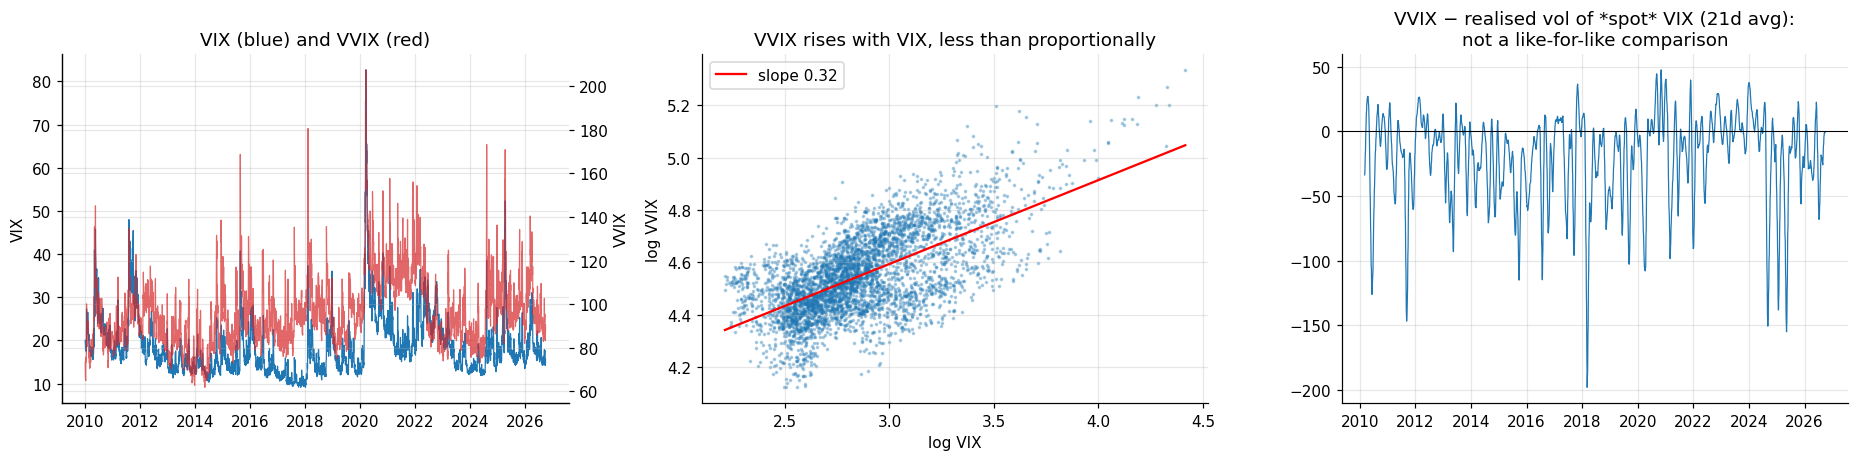

,VIX peak,VIX peak date,VVIX peak,VVIX peak date,VVIX peak leads VIX peak (days),VVIX/VIX at VIX peak
episode,,,,,,
US downgrade 2011,48.0000,2011-08-08,134.6300,2011-08-08,0,2.8048
China deval. 2015,40.7400,2015-08-24,168.7500,2015-08-24,0,4.1421
Volmageddon 2018,37.3200,2018-02-05,180.6100,2018-02-08,-3,4.7519
COVID 2020,82.6900,2020-03-16,207.5900,2020-03-16,0,2.5105
2022 bear,36.4500,2022-03-07,154.3800,2022-01-24,42,3.6669
Yen carry unwind 2024,38.5700,2024-08-05,173.3200,2024-08-05,0,4.4936
Tariff shock 2025,52.3300,2025-04-08,170.9200,2025-04-08,0,3.2662


unconditional median VVIX/VIX = 5.61


In [2]:
d = lv[["VIX", "VVIX"]].dropna()
d["rv_logVIX"] = np.log(d.VIX).diff().rolling(21).std() * np.sqrt(252) * 100     # realised vol of VIX (%)
fig, axs = plt.subplots(1, 3, figsize=(17, 4.3))
axs[0].plot(d.index, d.VIX, lw=.8, label="VIX"); ax2 = axs[0].twinx(); ax2.plot(d.index, d.VVIX, lw=.8, color="tab:red", alpha=.7, label="VVIX")
axs[0].set_title("VIX (blue) and VVIX (red)"); axs[0].set_ylabel("VIX"); ax2.set_ylabel("VVIX")
axs[1].scatter(np.log(d.VIX), np.log(d.VVIX), s=2, alpha=.3)
b = sm.OLS(np.log(d.VVIX), sm.add_constant(np.log(d.VIX))).fit()
xx = np.linspace(np.log(d.VIX).min(), np.log(d.VIX).max(), 50)
axs[1].plot(xx, b.params.iloc[0] + b.params.iloc[1] * xx, "r-", label=f"slope {b.params.iloc[1]:.2f}")
axs[1].set_xlabel("log VIX"); axs[1].set_ylabel("log VVIX"); axs[1].legend(); axs[1].set_title("VVIX rises with VIX, less than proportionally")
axs[2].plot(d.index, (d.VVIX - d.rv_logVIX).rolling(21).mean(), lw=.8)
axs[2].axhline(0, color="k", lw=.7); axs[2].set_title("VVIX − realised vol of *spot* VIX (21d avg):\nnot a like-for-like comparison")
plt.tight_layout(); plt.show()

episodes = {"US downgrade 2011": ("2011-07-15", "2011-10-31"), "China deval. 2015": ("2015-08-01", "2015-09-30"),
            "Volmageddon 2018": ("2018-01-25", "2018-02-28"), "COVID 2020": ("2020-02-15", "2020-04-30"),
            "2022 bear": ("2022-01-01", "2022-10-31"), "Yen carry unwind 2024": ("2024-07-25", "2024-08-20"),
            "Tariff shock 2025": ("2025-03-25", "2025-04-30")}
ep = []
for n, (a, z) in episodes.items():
    w = d.loc[a:z]
    ep.append({"episode": n, "VIX peak": w.VIX.max(), "VIX peak date": w.VIX.idxmax().date(), "VVIX peak": w.VVIX.max(),
               "VVIX peak date": w.VVIX.idxmax().date(), "VVIX peak leads VIX peak (days)": (w.VIX.idxmax() - w.VVIX.idxmax()).days,
               "VVIX/VIX at VIX peak": w.VVIX[w.VIX.idxmax()] / w.VIX.max()})
display(pd.DataFrame(ep).set_index("episode"))
print(f"unconditional median VVIX/VIX = {(d.VVIX / d.VIX).median():.2f}")

**Facts to keep in mind.**
* log VVIX rises with log VIX with a slope of only ≈ 0.3: **percentage** vol-of-vol rises in stress, but far less than volatility itself.
  At the VIX peak of every episode, VVIX/VIX (2.5–4.8) is well below its normal level (≈ 5.6). The vol of VIX *in VIX points* explodes,
  while its vol *in percent* saturates.
* VVIX peaks on **the same day** as VIX in five of the seven episodes. The exceptions are 2022, a slow bear market where VVIX peaked in January,
  six weeks before VIX, and Feb-2018, when it peaked three days after the "Volmageddon" VIX spike as short-vol products were unwound.
* **A trap in the right-hand panel.** VVIX is usually *below* the realised volatility of spot VIX, which looks like a *negative* vol-of-vol risk
  premium, but the comparison isn't like-for-like. VIX options settle on VIX at expiry, so their implied vol prices the *30-day-forward* VIX.
  That behaves like a VIX future, which is far smoother than spot VIX. Spot VIX isn't tradable and mean-reverts within days, which inflates its daily
  realised vol. A proper premium measure compares VVIX with the realised vol of VIX *futures* (or of the option's own underlying).

## 3. Is volatility rough?
Following Gatheral, Jaisson & Rosenbaum (2018), take daily realised volatility $\sigma_t$ (from 5-minute ES returns during US hours) and compute
$$m(q,\Delta)=\big\langle|\log\sigma_{t+\Delta}-\log\sigma_t|^q\big\rangle .$$
If log-volatility is self-similar with Hurst exponent $H$, then $m(q,\Delta)\propto\Delta^{\zeta_q}$ with $\zeta_q=qH$. A classical diffusion
(Heston, SABR) has $H=\tfrac12$ at short lags.

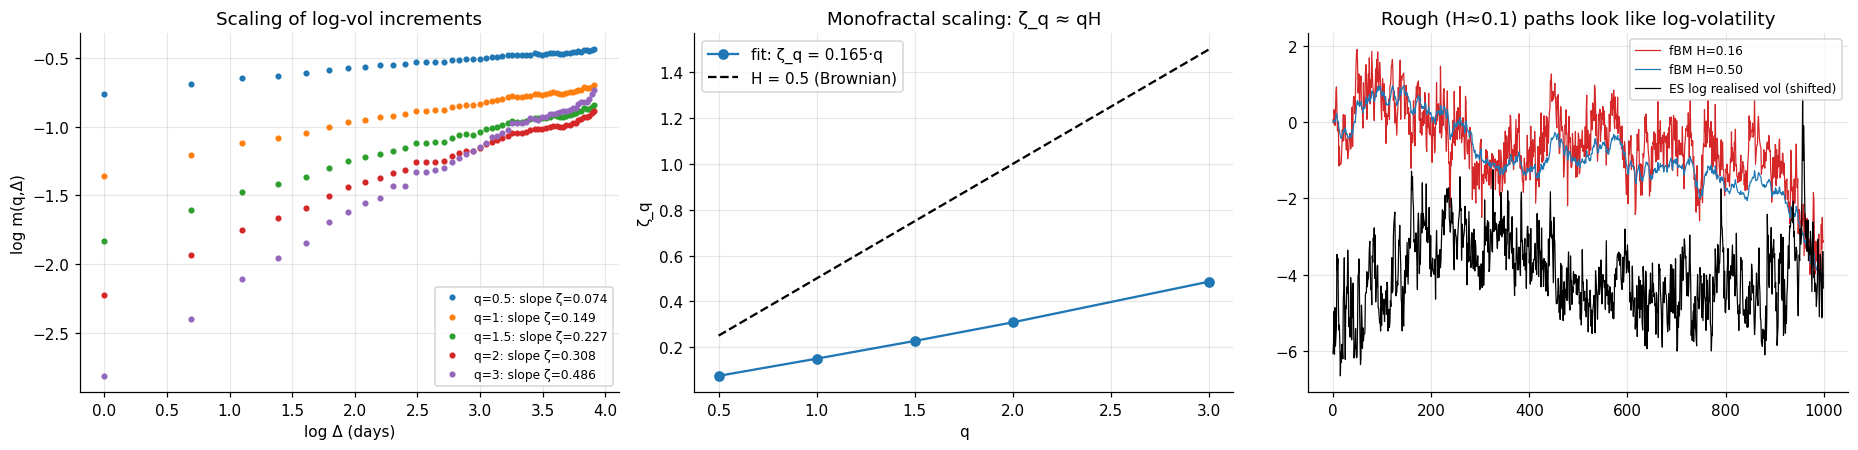

Estimated Hurst exponent of log realised volatility: H ≈ 0.165


In [3]:
rv = es_daily_realized_variance()
logsig = 0.5 * np.log(rv.rv * 252)
lags = np.arange(1, 51)
qs = [0.5, 1, 1.5, 2, 3]
zeta, mq = {}, {}
for q in qs:
    m = np.array([np.mean(np.abs(logsig.values[l:] - logsig.values[:-l]) ** q) for l in lags])
    mq[q] = m
    zeta[q] = np.polyfit(np.log(lags), np.log(m), 1)[0]
H_hat = np.polyfit(qs, [zeta[q] for q in qs], 1)[0]

fig, axs = plt.subplots(1, 3, figsize=(17, 4.2))
for q in qs:
    axs[0].plot(np.log(lags), np.log(mq[q]), "o", ms=3, label=f"q={q}: slope ζ={zeta[q]:.3f}")
axs[0].set_xlabel("log Δ (days)"); axs[0].set_ylabel("log m(q,Δ)"); axs[0].legend(fontsize=8); axs[0].set_title("Scaling of log-vol increments")
axs[1].plot(qs, [zeta[q] for q in qs], "o-", label=f"fit: ζ_q = {H_hat:.3f}·q")
axs[1].plot(qs, np.array(qs) * 0.5, "k--", label="H = 0.5 (Brownian)")
axs[1].set_xlabel("q"); axs[1].set_ylabel("ζ_q"); axs[1].legend(); axs[1].set_title("Monofractal scaling: ζ_q ≈ qH")
# a simulated fBM with the estimated H vs a Brownian motion, for intuition
n = 1000; tgrid = np.arange(1, n + 1)
cov = lambda h: 0.5 * (np.abs(tgrid[:, None]) ** (2 * h) + np.abs(tgrid[None, :]) ** (2 * h) - np.abs(tgrid[:, None] - tgrid[None, :]) ** (2 * h))
zz = np.random.default_rng(0).standard_normal(n)
for h, c in [(H_hat, "tab:red"), (0.5, "tab:blue")]:
    path = np.linalg.cholesky(cov(h) + 1e-10 * np.eye(n)) @ zz
    axs[2].plot(path / path.std(), color=c, lw=.8, label=f"fBM H={h:.2f}")
axs[2].plot((logsig.values[-n:] - logsig.values[-n:].mean()) / logsig.values[-n:].std() - 4, color="k", lw=.8, label="ES log realised vol (shifted)")
axs[2].legend(fontsize=8); axs[2].set_title("Rough (H≈0.1) paths look like log-volatility")
plt.tight_layout(); plt.show()
print(f"Estimated Hurst exponent of log realised volatility: H ≈ {H_hat:.3f}")

The increments scale with a **single** exponent $H$ that is far below ½. Log-volatility is rough, just as Gatheral–Jaisson–Rosenbaum found
on many indices. (Caveat: realised variance contains measurement error, which biases $H$ downwards; corrected estimates are typically
0.05–0.15, so the qualitative conclusion stands.) A rough fBM path (red) looks strikingly like the ES log-vol series, while a Brownian path is far
too smooth.

## 4. The SPX ATM-skew term structure
Rough volatility predicts $\psi(T)=\big|\partial_k\sigma_{BS}(k,T)\big|_{k=0}\propto T^{H-1/2}$. We estimate the ATM skew for each SPX expiry from
the snapshot (forward from put–call parity, OTM implied vols, local quadratic fit near the money), then fit a power law.

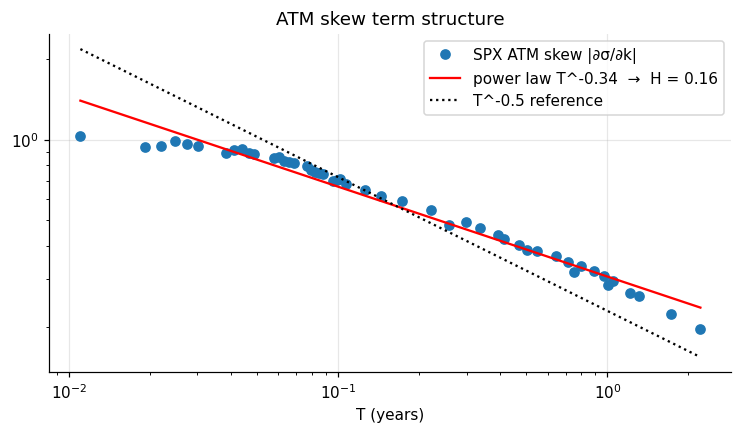

In [4]:
def black76(F, K, T, s, Dsc, call):
    sd = s * np.sqrt(T); d1 = (np.log(F / K) + 0.5 * sd * sd) / sd; d2 = d1 - sd
    return Dsc * (F * norm.cdf(d1) - K * norm.cdf(d2)) if call else Dsc * (K * norm.cdf(-d2) - F * norm.cdf(-d1))


def iv_b76(price, F, K, T, Dsc, call):
    intrinsic = Dsc * max((F - K) if call else (K - F), 0)
    if not np.isfinite(price) or price <= intrinsic + 1e-10:
        return np.nan
    try:
        return brentq(lambda s: black76(F, K, T, s, Dsc, call) - price, 1e-4, 8.0)
    except ValueError:
        return np.nan


r_sofr = fred_rates()["SOFR"].dropna().iloc[-1] / 100


def chain_ivs(und, settle_hour=16.0, min_T=4 / 365):
    c = option_chains()
    c = c[c.underlying == und].copy()
    c["root"] = c.contractSymbol.str.extract(r"^([A-Z]+)")[0]
    major = c.groupby(["expiry", "root"]).size().reset_index().sort_values(0).drop_duplicates("expiry", keep="last")
    c = c.merge(major[["expiry", "root"]], on=["expiry", "root"])
    hrs = np.where(c.root.eq("SPX") | (und == "^VIX"), 9.5, settle_hour)       # AM-settled: SPX monthlies and VIX options
    c["T"] = ((pd.to_datetime(c.expiry) + pd.to_timedelta(hrs, unit="h")) - SNAP) / pd.Timedelta(days=365)
    c["mid"] = (c.bid + c.ask) / 2
    c = c[(c.bid > 0) & (c.ask > c.bid) & (c["T"] > min_T) & ((c.ask - c.bid) / c.mid < 0.5)]
    out = []
    for e, g in c.groupby("expiry"):
        T = g["T"].iloc[0]; Dsc = np.exp(-r_sofr * T)
        cc, pp = g[g.type == "C"].set_index("strike").mid, g[g.type == "P"].set_index("strike").mid
        both = (cc - pp).dropna()
        if len(both) < 3:
            continue
        near = both.abs().nsmallest(6).index
        F = np.median(near.values + both.loc[near].values / Dsc)
        otm = g[((g.type == "P") & (g.strike < F)) | ((g.type == "C") & (g.strike >= F))]
        for r in otm.itertuples():
            out.append(dict(expiry=e, T=T, F=F, D=Dsc, K=r.strike, k=np.log(r.strike / F), type=r.type, bid=r.bid, ask=r.ask,
                            iv=iv_b76(r.mid, F, r.strike, T, Dsc, r.type == "C"),
                            iv_bid=iv_b76(r.bid, F, r.strike, T, Dsc, r.type == "C"),
                            iv_ask=iv_b76(r.ask, F, r.strike, T, Dsc, r.type == "C")))
    return pd.DataFrame(out).dropna(subset=["iv"])


spx = chain_ivs("^SPX")
skew = []
for e, g in spx.groupby("expiry"):
    T = g["T"].iloc[0]
    band = 0.25 * np.sqrt(T) * g.iv.median()            # ±~0.25 standard deviations
    gg = g[g.k.abs() < max(band, 0.01)]
    if len(gg) < 5 or T > 3:
        continue
    c2, c1, c0 = np.polyfit(gg.k, gg.iv, 2)
    skew.append({"expiry": e, "T": T, "atm_vol": c0, "atm_skew": -c1})
skew = pd.DataFrame(skew).set_index("expiry")
pl = np.polyfit(np.log(skew["T"]), np.log(skew.atm_skew), 1)
H_skew = pl[0] + 0.5

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(skew["T"], skew.atm_skew, "o", label="SPX ATM skew |∂σ/∂k|")
tt = np.geomspace(skew["T"].min(), skew["T"].max(), 50)
ax.loglog(tt, np.exp(pl[1]) * tt ** pl[0], "r-", label=f"power law T^{pl[0]:.2f}  →  H = {H_skew:.2f}")
ax.loglog(tt, np.exp(pl[1]) * tt[len(tt)//2] ** pl[0] * (tt / tt[len(tt)//2]) ** -0.5, "k:", label="T^-0.5 reference")
ax.set_xlabel("T (years)"); ax.legend(); ax.set_title("ATM skew term structure"); plt.show()

From about one month to two years the ATM skew follows a power law, $\psi(T)\propto T^{-0.34}$, which implies $H\approx0.16$. That is remarkably
close to the realised-volatility estimate in §3, although the two needn't agree: the option-implied exponent is a risk-neutral quantity that also
reflects spot–vol correlation. Below ~2 weeks the measured skew flattens. At the very short end, the local quadratic fit over a narrow strike band
and event risk (weekend/CPI/FOMC days inside the window) both distort the estimate. A classical one-factor stochastic-vol model predicts a skew that
is *flat* for short maturities and decays like $1/T$ for long ones, which is not what we see in the middle of the curve.

## 5. SABR on SPX smiles: the vol-of-vol term structure
With $\beta=1$, Hagan's lognormal implied-vol approximation is
$$\sigma_{BS}(K)=\alpha\,\frac{z}{x(z)}\Big[1+\Big(\frac{\rho\nu\alpha}{4}+\frac{2-3\rho^2}{24}\nu^2\Big)T\Big],\quad z=\frac{\nu}{\alpha}\ln\frac FK,\quad x(z)=\ln\frac{\sqrt{1-2\rho z+z^2}+z-\rho}{1-\rho}.$$
SABR is calibrated **per expiry**. If a single diffusion described the market, $\nu$ would be roughly constant across expiries. Instead:

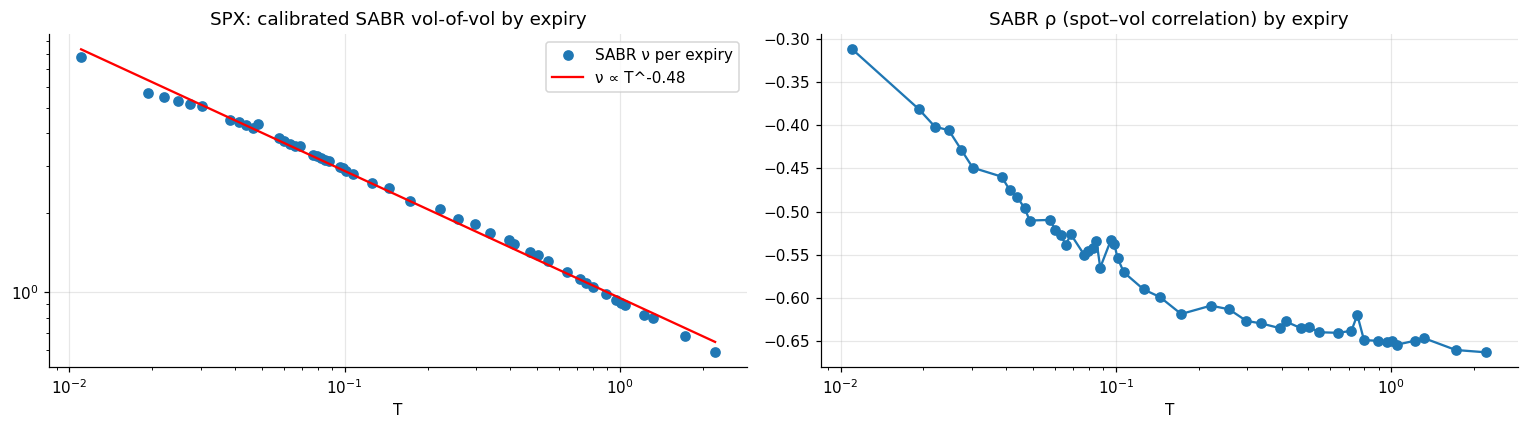

median SABR fit RMSE on SPX: 0.52 vol pts


In [5]:
def sabr_iv(k, T, alpha, rho, nu):
    """Hagan (2002) lognormal vol for beta=1; k = ln(K/F)."""
    z = -nu / alpha * k
    x = np.log((np.sqrt(1 - 2 * rho * z + z * z) + z - rho) / (1 - rho))
    zx = np.where(np.abs(z) < 1e-8, 1.0, z / np.where(np.abs(x) < 1e-12, 1e-12, x))
    return alpha * zx * (1 + (rho * nu * alpha / 4 + (2 - 3 * rho ** 2) / 24 * nu ** 2) * T)


def fit_sabr(g, rho_bounds=(-0.999, 0.999)):
    T = g["T"].iloc[0]
    w = 1 / np.maximum((g.iv_ask - g.iv_bid).fillna(0.05).values, 0.003)
    f = lambda p: np.sqrt(w) * (sabr_iv(g.k.values, T, *p) - g.iv.values)
    best = None
    for r0 in (-0.7, 0.0, 0.5):
        for n0 in (0.5, 2.0):
            x0 = [np.interp(0, g.k, g.iv) if g.k.min() < 0 < g.k.max() else g.iv.median(), np.clip(r0, *rho_bounds), n0]
            r = least_squares(f, x0, bounds=([1e-3, rho_bounds[0], 1e-3], [5, rho_bounds[1], 20]))
            if best is None or r.cost < best.cost:
                best = r
    a, rho, nu = best.x
    rmse = np.sqrt(np.mean((sabr_iv(g.k.values, T, a, rho, nu) - g.iv.values) ** 2)) * 100
    return dict(T=T, alpha=a, rho=rho, nu=nu, rmse_volpts=rmse)


sabr_spx = pd.DataFrame({e: fit_sabr(g[(g.k > -0.5) & (g.k < 0.2)].sort_values("k"))
                         for e, g in spx.groupby("expiry") if g["T"].iloc[0] < 3 and len(g) > 15}).T.astype(float)
pn = np.polyfit(np.log(sabr_spx["T"]), np.log(sabr_spx.nu), 1)
fig, axs = plt.subplots(1, 2, figsize=(14, 4))
axs[0].loglog(sabr_spx["T"], sabr_spx.nu, "o", label="SABR ν per expiry")
axs[0].loglog(sabr_spx["T"], np.exp(pn[1]) * sabr_spx["T"] ** pn[0], "r-", label=f"ν ∝ T^{pn[0]:.2f}")
axs[0].set_xlabel("T"); axs[0].set_title("SPX: calibrated SABR vol-of-vol by expiry"); axs[0].legend()
axs[1].semilogx(sabr_spx["T"], sabr_spx.rho, "o-"); axs[1].set_title("SABR ρ (spot–vol correlation) by expiry"); axs[1].set_xlabel("T")
plt.tight_layout(); plt.show()
print(f"median SABR fit RMSE on SPX: {sabr_spx.rmse_volpts.median():.2f} vol pts")

**Vol-of-vol is maturity-dependent**: short expiries need a huge ν, long ones a small ν, decaying roughly as a power of $T$. Each SABR slice fits
well, but the family of slices isn't one model. This is the SABR view of the same phenomenon as §4: a single-timescale diffusion for volatility
can't produce both the short-dated and the long-dated smile. Bergomi's answer is a *term structure of forward variances*, each driven by
factors with different mean-reversion speeds. The rough answer is a power-law kernel, which is effectively a continuum of timescales.

## 6. Calibrating to VIX options
VIX options are European options on the VIX index at expiry, $\text{VIX}_T=\sqrt{\tfrac{1}{\Delta}\int_T^{T+\Delta}\xi_T(u)\,du}$ with $\Delta=30$ days,
where $\xi_T(u)=E_T[v_u]$ is the forward-variance curve at $T$. Their forward (the VIX future) comes from put–call parity on the VIX chain.

In both Bergomi-type models, $\log\xi_T(u)$ is **Gaussian** given $\xi_0$, so we can simulate $\text{VIX}_T$ **exactly**. There are no paths: just a
correlated Gaussian vector over a grid of $u\in[T,T+\Delta]$.
* 1F Bergomi: $\log\xi_T(u)=\log\xi_0(u)+\omega\,G_u-\tfrac{\omega^2}{2}\text{Var}(G_u)$, $G_u=\int_0^Te^{-k(u-s)}dW_s$, $\text{Cov}(G_u,G_{u'})=e^{-k(u+u')}\frac{e^{2kT}-1}{2k}$;
* rough Bergomi: $G_u=\sqrt{2H}\int_0^T(u-s)^{H-1/2}dW_s$ with $\text{Cov}(G_u,G_{u'})=2H\int_0^T(u-s)^{H-1/2}(u'-s)^{H-1/2}ds$ (by quadrature), vol-of-vol $\eta$.

**Forward variance.** For each VIX expiry we set $\xi_0$ flat on $[T,T+\Delta]$ at the level that makes the model's $E[\text{VIX}_T]$ equal the market VIX
forward, so the models match the futures exactly and are judged purely on the **smile**. (It's a slice-wise simplification of a full $\xi_0(u)$ curve.)
The model's vol-of-vol parameters are then fitted jointly across all expiries.

In [6]:
vix = chain_ivs("^VIX", min_T=5 / 365)
vix = vix[(vix.k > -0.4) & (vix.k < 0.9)]          # ~10–90 delta: far-OTM VIX calls are illiquid lottery tickets
vfw = vix.groupby("expiry").agg(T=("T", "first"), F=("F", "first"), D=("D", "first"), n=("k", "size"))
vfw = vfw[vfw.n >= 8]
vix = vix[vix.expiry.isin(vfw.index)]
print(f"VIX options: {len(vix)} OTM quotes on {len(vfw)} expiries; VIX spot {lv.VIX.iloc[-1]:.2f}")
display(vfw[["T", "F"]].rename(columns={"F": "VIX forward (parity)"}).T)

sabr_vix = pd.DataFrame({e: fit_sabr(g.sort_values("k"), rho_bounds=(-0.999, 0.999)) for e, g in vix.groupby("expiry")}).T.astype(float)

DELTA, NU_GRID, NSIM = 30 / 365, 12, 60_000
Z_CRN = np.random.default_rng(3).standard_normal((NSIM, NU_GRID))        # common random numbers → smooth objective


def cov_G(T, model, p):
    u = T + (np.arange(NU_GRID) + 0.5) / NU_GRID * DELTA
    if model == "bergomi":
        k = p
        return u, np.exp(-k * (u[:, None] + u[None, :])) * (np.exp(2 * k * T) - 1) / (2 * k)
    H = p
    x = np.r_[0, np.geomspace(1e-6, T, 400)]                                 # x = T - s
    f = (u[:, None] - T + x[None, :]) ** (H - 0.5)                          # (u - s)^(H-1/2)
    integrand = f[:, None, :] * f[None, :, :]
    return u, 2 * H * np.trapezoid(integrand, x, axis=2)


def vix_unit(T, model, vov, p2):
    """VIX_T (in vol units) for xi_0 ≡ 1 on the window; scale by sqrt(level) afterwards."""
    u, C = cov_G(T, model, p2)
    L = np.linalg.cholesky(C + 1e-14 * np.eye(len(u)))
    G = Z_CRN @ L.T
    xi = np.exp(vov * G - 0.5 * vov ** 2 * np.diag(C))
    return np.sqrt(xi.mean(1))


def model_vix_prices(model, vov, p2):
    out = []
    for e, row in vfw.iterrows():
        vu = vix_unit(row["T"], model, vov, p2)
        VT = row.F / vu.mean() * vu                        # match the VIX future exactly
        g = vix[vix.expiry == e]
        for r in g.itertuples():
            call = r.type == "C"
            out.append(row.D * np.mean(np.maximum(VT - r.K, 0) if call else np.maximum(r.K - VT, 0)))
    return np.array(out)


def model_vix_ivs(model, vov, p2):
    P = model_vix_prices(model, vov, p2)
    return np.array([iv_b76(pr, r.F, r.K, r.T, r.D, r.type == "C") for pr, r in zip(P, vix_sorted.itertuples())])


vix_sorted = pd.concat([vix[vix.expiry == e] for e in vfw.index])
wv = 1 / np.maximum((vix_sorted.iv_ask - vix_sorted.iv_bid).fillna(0.2).values, 0.02)
mkt_px = np.array([black76(r.F, r.K, r.T, r.iv, r.D, r.type == "C") for r in vix_sorted.itertuples()])
vega = np.array([r.D * r.F * norm.pdf((np.log(r.F / r.K) + 0.5 * r.iv ** 2 * r.T) / (r.iv * np.sqrt(r.T))) * np.sqrt(r.T)
                 for r in vix_sorted.itertuples()])


def calib(model, x0, bounds):
    """Vega-weighted price errors ≈ implied-vol errors, but defined even where the model price is ~0 (no NaN IVs)."""
    def obj(x):
        err = (model_vix_prices(model, *x) - mkt_px) / np.maximum(vega, 1e-3)
        return np.sum(wv * err ** 2) / wv.sum()
    best = None
    for x_start in x0:
        r = minimize(obj, x_start, method="Nelder-Mead", bounds=bounds, options={"xatol": 1e-3, "fatol": 1e-8, "maxiter": 200})
        if best is None or r.fun < best.fun:
            best = r
    return best.x, np.sqrt(best.fun) * 100


t0 = time.time()
par_b, rmse_b = calib("bergomi", [[1.5, 1.0], [2.5, 3.0]], [(0.2, 8), (0.05, 20)])
par_r, rmse_r = calib("rough", [[1.2, 0.1], [2.0, 0.3]], [(0.2, 8), (0.01, 0.49)])
print(f"calibrated in {time.time()-t0:.0f}s")
vix_sorted = vix_sorted.assign(iv_bergomi=model_vix_ivs("bergomi", *par_b), iv_rough=model_vix_ivs("rough", *par_r))
vix_sorted["iv_sabr"] = [sabr_iv(k, T, *sabr_vix.loc[e, ["alpha", "rho", "nu"]].values) for e, k, T in
                         zip(vix_sorted.expiry, vix_sorted.k, vix_sorted["T"])]
summary = pd.DataFrame({
    "SABR (3 params per expiry)": {"params": f"{3*len(vfw)} total", "RMSE (vol pts)": 100 * np.sqrt(np.mean((vix_sorted.iv_sabr - vix_sorted.iv) ** 2))},
    "1F Bergomi (ω, k)": {"params": f"ω={par_b[0]:.2f}, k={par_b[1]:.2f}", "RMSE (vol pts)": 100 * np.sqrt(np.nanmean((vix_sorted.iv_bergomi - vix_sorted.iv) ** 2))},
    "rough Bergomi (η, H)": {"params": f"η={par_r[0]:.2f}, H={par_r[1]:.3f}", "RMSE (vol pts)": 100 * np.sqrt(np.nanmean((vix_sorted.iv_rough - vix_sorted.iv) ** 2))}}).T
summary

VIX options: 289 OTM quotes on 10 expiries; VIX spot 14.87


expiry,2026-10-07,2026-10-14,2026-10-21,2026-11-18,2026-12-16,2027-01-20,2027-02-17,2027-03-17,2027-04-21,2027-05-18
T,0.0240,0.0432,0.0623,0.1391,0.2158,0.3117,0.3884,0.4651,0.5610,0.6350
VIX forward (parity),17.1032,17.5008,17.6673,18.4173,18.8151,19.5171,19.9645,20.1818,20.5851,20.6902


calibrated in 10s


,params,RMSE (vol pts)
SABR (3 params per expiry),30 total,1.7252
"1F Bergomi (ω, k)","ω=2.06, k=1.87",38.3240
"rough Bergomi (η, H)","η=1.29, H=0.195",36.4387


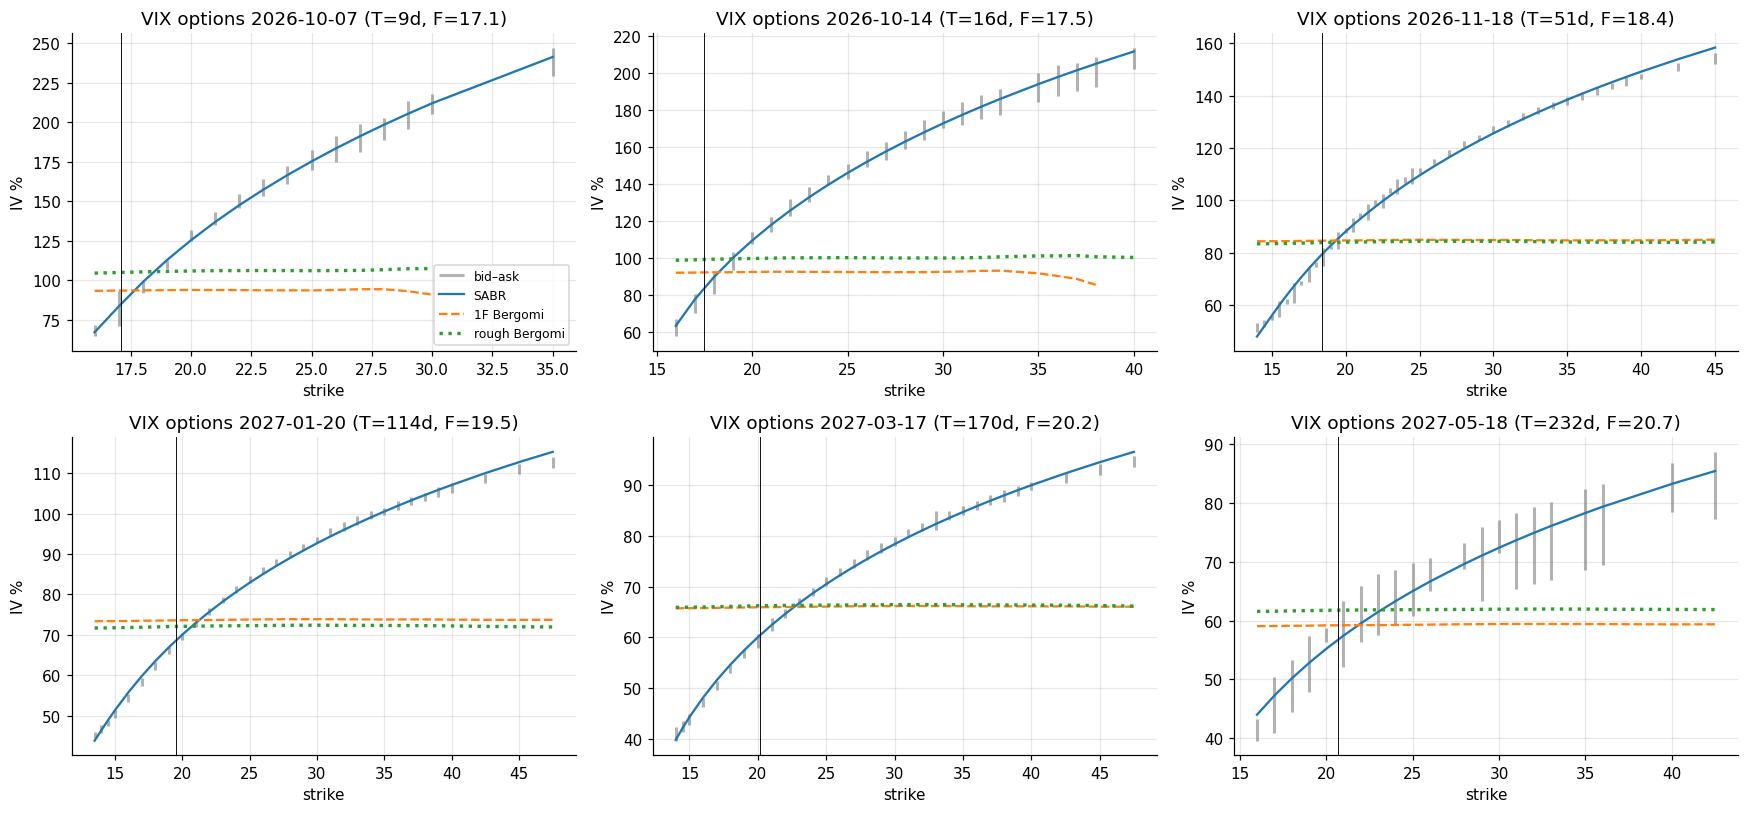

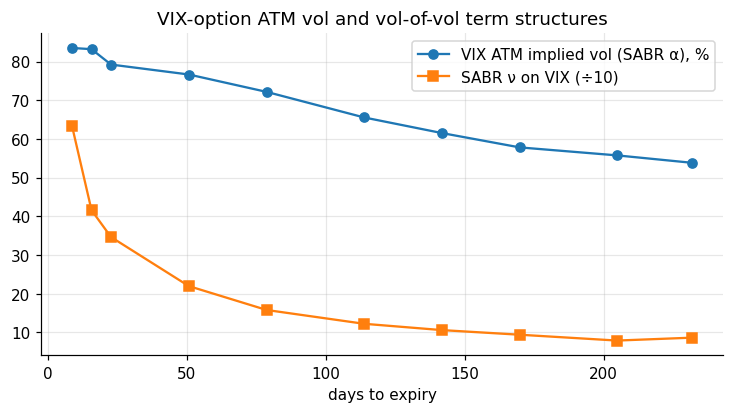

In [7]:
show = list(vfw.index[np.linspace(0, len(vfw) - 1, 6).astype(int)])
fig, axs = plt.subplots(2, 3, figsize=(16, 7.5))
for ax, e in zip(axs.ravel(), show):
    g = vix_sorted[vix_sorted.expiry == e].sort_values("k")
    ax.vlines(g.K, g.iv_bid * 100, g.iv_ask * 100, color="grey", lw=2, alpha=.6, label="bid–ask")
    ax.plot(g.K, g.iv_sabr * 100, "-", label="SABR")
    ax.plot(g.K, g.iv_bergomi * 100, "--", label="1F Bergomi")
    ax.plot(g.K, g.iv_rough * 100, ":", lw=2.2, label="rough Bergomi")
    ax.axvline(vfw.loc[e, "F"], color="k", lw=.6)
    ax.set_title(f"VIX options {e} (T={vfw.loc[e,'T']*365:.0f}d, F={vfw.loc[e,'F']:.1f})"); ax.set_xlabel("strike"); ax.set_ylabel("IV %")
axs[0, 0].legend(fontsize=8); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(sabr_vix["T"] * 365, sabr_vix.alpha * 100, "o-", label="VIX ATM implied vol (SABR α), %")
ax.plot(sabr_vix["T"] * 365, sabr_vix.nu * 100 / 10, "s-", label="SABR ν on VIX (÷10)")
ax.set_xlabel("days to expiry"); ax.legend(); ax.set_title("VIX-option ATM vol and vol-of-vol term structures"); plt.show()

**What the calibration shows.**
* ATM VIX implied vol is high (≈ 80 % at one week, ≈ 60 % at eight months) and falls with maturity. VIX's own volatility mean-reverts fast, which the
  Bergomi-type models capture through the kernel ($k$, or roughness $H$) and SABR through a separate ν per expiry.
* The **VIX smile slopes steeply upward**, from ~40–60 % for low strikes to 150–240 % for high strikes. OTM VIX calls are expensive because they are
  crash insurance. SABR reproduces each slice almost within the bid–ask spread, with ρ ≈ +1 between VIX and its own volatility.
* Both Bergomi-type models make $\log\text{VIX}_T$ close to Gaussian, so their VIX smiles are almost **flat**. The calibration settles on a
  level near the ATM vol of each expiry (rough Bergomi finds $H\approx0.2$, in the same range as §3–4), but they can't produce the skew. That is why
  their RMSE is tens of vol points. This is the heart of the **SPX/VIX joint-calibration problem** (Guyon 2020): models that fit
  SPX skew (needing large vol-of-vol and strongly negative spot–vol correlation) produce the wrong VIX-smile shape. Fixes include
  two-factor Bergomi with *skewed* factor mixtures, the **quintic OU** model (Abi Jaber, Illand & Li 2022), and Guyon's path-dependent volatility.

## 7. Stress: how likely is a VIX spike?
The calibrated models define the risk-neutral distribution of VIX one month ahead. We compare the probability of a spike **from calm conditions**
(VIX ≈ 15 today) to at least 25 or 30 within ~one month with the historical frequency over 2010–2026. If the market charges a premium for crash
insurance, risk-neutral probabilities should be at least as high as historical ones.

In [8]:
T1 = 30 / 365
calm = d[(d.VIX > 13) & (d.VIX < 17)]
fwd21 = d.VIX.shift(-21).reindex(calm.index).dropna()
fwdmax = d.VIX[::-1].rolling(21, min_periods=21).max()[::-1].shift(-1).reindex(calm.index).dropna()
hist = {"P(VIX in 21d ≥ 25)": (fwd21 >= 25).mean(), "P(VIX in 21d ≥ 30)": (fwd21 >= 30).mean(),
        "P(max VIX over next 21d ≥ 30)": (fwdmax >= 30).mean()}
F_calm = 16.0                                   # VIX future ~1 month out when spot VIX ≈ 15 (typical contango)
rows = {"historical (from VIX 13–17)": hist}
for name, model, par in [("1F Bergomi (calibrated)", "bergomi", par_b), ("rough Bergomi (calibrated)", "rough", par_r)]:
    vu = vix_unit(T1, model, *par)
    VT = F_calm * vu / vu.mean()
    rows[name] = {"P(VIX in 21d ≥ 25)": (VT >= 25).mean(), "P(VIX in 21d ≥ 30)": (VT >= 30).mean(), "P(max VIX over next 21d ≥ 30)": np.nan}
a0, r0_, n0 = sabr_vix.iloc[(sabr_vix["T"] - T1).abs().argmin()][["alpha", "rho", "nu"]]
# SABR (β=1) terminal distribution via its smile: risk-neutral P(VIX_T ≥ K) = -∂C/∂K / D
Kg = np.linspace(8, 60, 800)
C = np.array([black76(F_calm, K, T1, sabr_iv(np.log(K / F_calm), T1, a0, r0_, n0), 1.0, True) for K in Kg])
surv = -np.gradient(C, Kg)
rows["SABR (1m slice)"] = {"P(VIX in 21d ≥ 25)": np.interp(25, Kg, surv), "P(VIX in 21d ≥ 30)": np.interp(30, Kg, surv), "P(max VIX over next 21d ≥ 30)": np.nan}
pd.DataFrame(rows).T.style.format("{:.1%}", na_rep="—")

,P(VIX in 21d ≥ 25),P(VIX in 21d ≥ 30),P(max VIX over next 21d ≥ 30)
historical (from VIX 13–17),3.4%,2.0%,4.5%
1F Bergomi (calibrated),3.1%,0.5%,—
rough Bergomi (calibrated),3.4%,0.6%,—
SABR (1m slice),3.6%,2.0%,—


**Reading the table.**
* Historically, starting from VIX 13–17, VIX was ≥ 30 one month later only ~2 % of the time, and *touched* 30 within the month ~4–5 % of the time
  (Aug-2015, Feb-2018, Mar-2020, Aug-2024, Apr-2025 were all sudden).
* The **flat-smile Bergomi models give 3–4× too little probability** to a spike to 30. They were fitted to the ATM part of the VIX smile and have no way to
  fatten the right tail. This is the stress-testing consequence of the smile misfit in §6: a risk system built on them would understate the VIX-call
  exposure of a short-vol book.
* The **SABR slice**, which does fit the upward VIX skew, implies a spike probability close to the historical frequency. (Different caveats apply to
  each row: risk-neutral vs physical probabilities, an assumed 1-month VIX future of 16, and a small historical sample with only a handful of spikes.)

**How volatility behaves under stress (summary of the evidence):**
1. Volatility jumps *up* fast and decays slowly. VIX's own vol (VVIX) spikes at the onset and peaks early.
2. Vol-of-vol in *percent* rises with the level of VIX but less than proportionally, so a lognormal (constant-ν) model for VIX overstates vol-of-vol at
   very high VIX and understates it at low VIX.
3. Roughness means very short-dated options and VIX futures react violently to shocks while long-dated ones barely move. That's the power-law term
   structures of skew (§4) and of vol-of-vol (§5).

## 8. Strengths, weaknesses and extensions
| Model | Strengths | Weaknesses |
|---|---|---|
| SABR | closed form, fits any single smile, intuitive parameters | no term-structure consistency (ν(T) must vary); Hagan's expansion can go arbitrageable in the wings/long T; no VIX consistency with SPX |
| 1F Bergomi | consistent forward-variance dynamics, exact VIX pricing, fast | one timescale can't fit short and long skews together; lognormal VIX, so a flat VIX smile |
| rough Bergomi | power-law skew with 3 parameters; matches realised-vol roughness | SPX pricing needs heavy Monte Carlo (non-Markovian); still a near-flat VIX smile; hedging/numerics harder |

**Caveats.** A single option snapshot; slice-wise flat forward variance for VIX calibration; Monte Carlo noise (common random numbers keep the
objective smooth); realised-vol-based $H$ is biased by microstructure noise; ES realised vol covers US hours only (no overnight).

**Extensions.** Joint SPX/VIX calibration (quintic OU, 2F Bergomi with skewed mixtures); price SPX options under rough Bergomi with the hybrid
scheme (Bennedsen, Lunde & Pakkanen 2017) and compare with the SSVI surface of Project 1; estimate $H$ over time and in stress sub-samples; a VIX
futures term-structure trading study (roll yield vs spike risk).

**References.** Hagan, Kumar, Lesniewski & Woodward, "Managing smile risk" (2002); Bergomi, *Stochastic Volatility Modeling* (2016); Gatheral,
Jaisson & Rosenbaum, "Volatility is rough", *Quant. Finance* (2018); Bayer, Friz & Gatheral, "Pricing under rough volatility" (2016); Guyon,
"The joint S&P 500/VIX smile calibration puzzle solved", *Risk* (2020); Abi Jaber, Illand & Li, "The quintic Ornstein–Uhlenbeck volatility model" (2022).